In [1]:
import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Dataencoder\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [3]:
import pandas as pd

news_df = pd.read_csv("../data/raw/raw_analyst_ratings.csv")

In [4]:
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

news_df['sentiment'] = news_df['headline'].apply(
    lambda x: sia.polarity_scores(x)['compound']
)

In [7]:
stock_df = pd.read_csv("../data/raw/AAPL.csv")

In [8]:
stock_df['daily_return'] = stock_df['Close'].pct_change() * 100

In [9]:
daily_sentiment = news_df.groupby(['date', 'stock'])['sentiment'].mean().reset_index()

In [16]:
daily_sentiment['date'] = pd.to_datetime(daily_sentiment['date'], format = 'mixed', utc = True).dt.date
stock_df['Date'] = pd.to_datetime(stock_df['Date'], format = 'mixed', utc = True).dt.date

In [17]:
merged = pd.merge(
    daily_sentiment,
    stock_df,
    left_on='date',
    right_on='Date',
    how='inner'
)

In [ ]:
from scipy.stats import pearsonr

df = merged[['sentiment', 'daily_return']].dropna()

print(len(df))

if len(df) >= 2:
    corr, p = pearsonr(df['sentiment'], df['daily_return'])
    print(corr, p)
else:
    print("Not enough overlapping data for correlation")

830236
0.06405295581481082 0.0


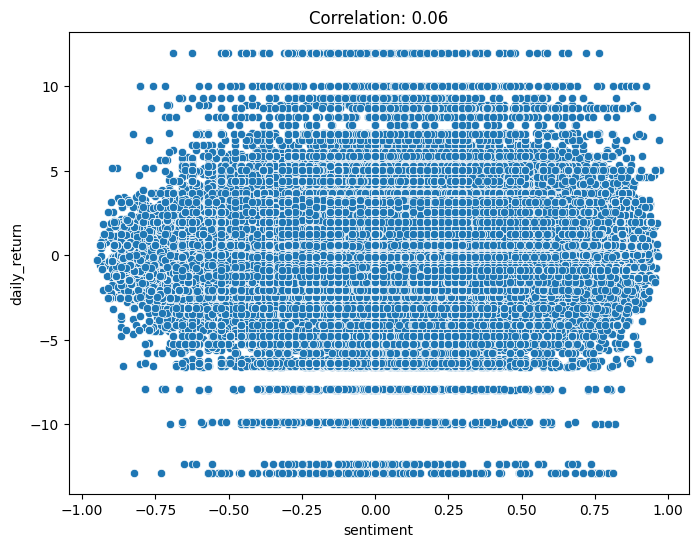

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.scatterplot(
    x='sentiment',
    y='daily_return',
    data=merged
)

plt.title(f"Correlation: {corr:.2f}")

plt.show()

In [22]:
def classify_sentiment(score):
    if score > 0.05:
        return 'Positive'
    elif score < -0.05:
        return 'Negative'
    else:
        return 'Neutral'

merged['sentiment_category'] = merged['sentiment'].apply(classify_sentiment)

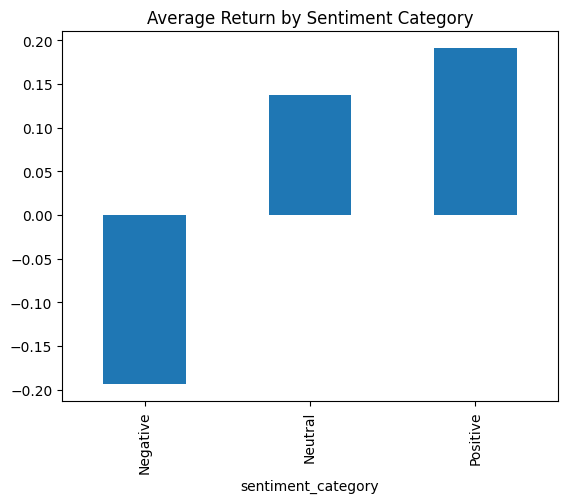

In [23]:
merged.groupby('sentiment_category')['daily_return'].mean().plot(kind='bar')

plt.title("Average Return by Sentiment Category")

plt.show()

## Correlation Interpretation

The Pearson correlation coefficient indicates the direction and strength of the relationship between news sentiment and stock returns.

A positive coefficient suggests that positive news sentiment is associated with positive stock returns, while a negative coefficient suggests the opposite.

The observed relationship may be influenced by confounding variables, delayed market reactions, and broader market conditions. Therefore, correlation should not be interpreted as causation.